In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import MemorySaver

In [2]:
model = ChatOllama(model="llama3.2")  


In [3]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [4]:
def chat_node(state: ChatState):

    # take user query from the state
    messages=state['messages']

    #send to llm
    response=model.invoke(messages)

    # response store state
    return {'messages':response}

In [5]:
checkpointer=MemorySaver()

graph=StateGraph(ChatState)

# add nodes
graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)

chatbot=graph.compile(checkpointer=checkpointer)

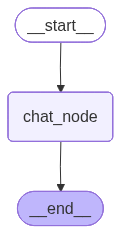

In [6]:
chatbot

In [7]:
initial_state={
    'messages':[HumanMessage(content='What is the Capital of Nepal')]
}
chatbot.invoke(initial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [8]:
thread_id='1'

while True:

    user_message=input('type here: ')

    print('User :',user_message)

    if user_message.strip().lower() in ['exit','quit','bye']:
        break

    config={'configurable':{'thread_id': thread_id}}
    response=chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    print('AI:',response['messages'][-1].content)


User : what is my name
AI: I don't know your name. I'm a large language model, I don't have the ability to access or store personal information about you, and our conversation just started. Would you like to share your name with me?
User : i am susan
AI: Nice to meet you, Susan! How can I assist you today? Is there something on your mind that you'd like to talk about, or perhaps some questions or topics you'd like to explore? I'm here to help.
User : what is my name
AI: You've already told me, Susan! We just had this conversation earlier. You're welcome to remind me anytime, though - it's not every day that someone checks their own name with a friendly AI like me!
User : bye


In [ ]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi i am susan', additional_kwargs={}, response_metadata={}, id='4f670c7d-64d5-4a21-976e-c6666204d556'), AIMessage(content="Hello Susan! It's nice to meet you. Is there something I can help you with, or would you like to chat for a bit?", additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-06-05T04:00:15.005909753Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5532872181, 'load_duration': 650023157, 'prompt_eval_count': 10, 'prompt_eval_duration': 2113164000, 'eval_count': 30, 'eval_duration': 2410446000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019e95f0-3af0-7380-9047-f06645cc54a1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 30, 'total_tokens': 40}), HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='6b474d8d-0046-4454-8794-dcf8e581f812'), AIMessage(content='Yo